In [1]:
# CELL 1: IMPORTS AND SETUP
# ============================================================================

import pandas as pd
import numpy as np
import requests
import os
import time
import random
import json
import hashlib
import faiss
import pickle
from datetime import datetime
from typing import Dict, List, Tuple, Optional, Union
from dataclasses import dataclass, asdict
from enum import Enum
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from IPython.display import display, HTML, clear_output
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# API clients
try:
    from openai import OpenAI
    OPENAI_AVAILABLE = True
    print("✅ OpenAI library available")
except ImportError:
    print("❌ OpenAI not installed. Install with: pip install openai")
    OPENAI_AVAILABLE = False

try:
    from groq import Groq
    GROQ_AVAILABLE = True
    print("✅ Groq library available")
except ImportError:
    print("❌ Groq not installed. Install with: pip install groq")
    GROQ_AVAILABLE = False

# Optional: LangSmith for observability
try:
    from langsmith import Client, traceable
    LANGSMITH_AVAILABLE = True
    print("✅ LangSmith available (optional)")
except ImportError:
    LANGSMITH_AVAILABLE = False
    print("📝 LangSmith not available (optional - install with: pip install langsmith)")

# Load environment variables
try:
    from dotenv import load_dotenv
    load_dotenv()
    print("✅ Environment variables loaded")
except ImportError:
    print("📝 python-dotenv not found. Set environment variables manually.")

# Configure display and warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_rows', 20)
plt.style.use('default')
sns.set_palette("husl")

print("\n" + "="*60)
print("🚀 ENHANCED HYBRID BEAUTY PRODUCT CLASSIFIER")
print("="*60)
print("📊 Using similar products context approach for optimal results")

✅ OpenAI library available
✅ Groq library available
✅ LangSmith available (optional)
✅ Environment variables loaded

🚀 ENHANCED HYBRID BEAUTY PRODUCT CLASSIFIER
📊 Using similar products context approach for optimal results


In [2]:
# CELL 2: CONFIGURATION CLASSES
# ============================================================================

class ClassificationStrategy(Enum):
    """Classification strategy options"""
    EMBEDDING_ONLY = "embedding_only"
    LLM_ONLY = "llm_only"
    HYBRID_CONSERVATIVE = "hybrid_conservative"  # Use LLM when confidence < 0.8
    HYBRID_BALANCED = "hybrid_balanced"          # Use LLM when confidence < 0.6
    HYBRID_AGGRESSIVE = "hybrid_aggressive"      # Use LLM when confidence < 0.4

@dataclass
class HybridConfig:
    """Configuration for the hybrid classification system"""
    
    # API Keys
    openai_api_key: str = os.getenv('OPENAI_API_KEY')
    groq_api_key: str = os.getenv('GROQ_API_KEY')
    
    # Model Configuration
    embedding_model: str = "text-embedding-3-large"
    llm_model: str = "openai/gpt-oss-120b"
    llm_fallback_models: List[str] = None
    
    # Hybrid Strategy
    strategy: ClassificationStrategy = ClassificationStrategy.HYBRID_BALANCED
    confidence_threshold: float = 0.4        # When to use LLM
    distance_threshold: float = 1.2          # Embedding distance threshold
    similarity_threshold: float = 0.85       # Cosine similarity threshold
    
    # File Paths
    dataset_path: str = "data/product_info_01.csv"
    categories_file: str = "data/product_descriptions_enhanced.csv"
    prompts_folder: str = "prompts"
    
    # Performance Settings
    sample_size: int = 50  # Reduced for testing
    random_state: int = 42
    max_embedding_batch_size: int = 50
    llm_rate_limit_delay: float = 0.5
    max_retries: int = 3
    
    # Caching
    enable_caching: bool = True
    cache_dir: str = "enhanced_cache"
    embedding_cache_file: str = "enhanced_embeddings.pkl"
    llm_cache_file: str = "enhanced_llm_cache.json"
    
    # Cost Tracking (approximate USD)
    embedding_cost_per_1k: float = 0.00013   # OpenAI embedding cost
    llm_cost_per_1k_tokens: float = 0.002    # Groq cost estimate
    
    def __post_init__(self):
        if self.llm_fallback_models is None:
            self.llm_fallback_models = [
                "deepseek-r1-distill-llama-70b",
                "llama-3.3-70b-versatile", 
                "meta-llama/llama-4-maverick-17b-128e-instruct"
            ]

# Initialize configuration
config = HybridConfig()

# Validation
if not config.openai_api_key:
    print("❌ OPENAI_API_KEY not found")
    print("💡 Get your API key from: https://platform.openai.com/api-keys")

if not config.groq_api_key:
    print("❌ GROQ_API_KEY not found") 
    print("💡 Get your API key from: https://console.groq.com/keys")

if config.openai_api_key and config.groq_api_key:
    print("✅ Both API keys configured")

print(f"\n🎯 ENHANCED CONFIGURATION:")
print(f"   Strategy: {config.strategy.value}")
print(f"   Confidence threshold: {config.confidence_threshold}")
print(f"   Sample size: {config.sample_size}")
print(f"   Caching: {config.enable_caching}")

✅ Both API keys configured

🎯 ENHANCED CONFIGURATION:
   Strategy: hybrid_balanced
   Confidence threshold: 0.4
   Sample size: 50
   Caching: True


In [3]:
# CELL 3: RESULT CLASSES AND UTILITIES  
# ============================================================================

@dataclass
class ClassificationResult:
    """Result from a single classification"""
    predicted_category: str
    confidence: float
    method_used: str  # 'embedding', 'llm', 'hybrid'
    processing_time: float
    cost_estimate: float = 0.0
    
    # Embedding-specific fields
    embedding_distance: Optional[float] = None
    embedding_similarity: Optional[float] = None
    embedding_top_k: Optional[List[Tuple[str, float]]] = None
    similar_products: Optional[List[Dict]] = None  # Enhanced: store similar products
    
    # LLM-specific fields
    llm_raw_response: Optional[str] = None
    llm_model_used: Optional[str] = None
    llm_tokens_used: Optional[int] = None
    
    # Metadata
    from_cache: bool = False
    timestamp: str = None
    error: Optional[str] = None
    accuracy: Optional[float] = None  # For evaluation
    
    def __post_init__(self):
        if self.timestamp is None:
            self.timestamp = datetime.now().isoformat()

# Utility functions
def calculate_cosine_similarity(vec1: np.ndarray, vec2: np.ndarray) -> float:
    """Calculate cosine similarity between two vectors"""
    dot_product = np.dot(vec1, vec2)
    norm_a = np.linalg.norm(vec1)
    norm_b = np.linalg.norm(vec2)
    return dot_product / (norm_a * norm_b) if (norm_a * norm_b) != 0 else 0.0

def get_cache_key(text: str, model: str = "") -> str:
    """Generate cache key for text and model combination"""
    content = f"{model}||{text}"
    return hashlib.md5(content.encode()).hexdigest()

def estimate_tokens(text: str) -> int:
    """Rough token estimation (4 chars ≈ 1 token)"""
    return len(text) // 4

print("✅ Enhanced utility classes and functions defined")

✅ Enhanced utility classes and functions defined


In [4]:
# CELL 4: EMBEDDING CLASSIFIER
# ============================================================================

class EnhancedEmbeddingClassifier:
    """Enhanced embedding classifier that returns similar products with context"""
    
    def __init__(self, config: HybridConfig):
        self.config = config
        self.client = OpenAI(api_key=config.openai_api_key)
        
        # Initialize storage
        self.category_embeddings = None
        self.category_names = []
        self.category_descriptions = []  # Store descriptions too
        self.product_data = []  # Store full product information
        self.faiss_index = None
        self.embedding_cache = {}
        
        # Statistics
        self.stats = {
            'embeddings_created': 0,
            'cache_hits': 0,
            'searches_performed': 0,
            'total_cost': 0.0
        }
        
    def load_embedding_cache(self):
        """Load embedding cache from disk"""
        cache_path = os.path.join(self.config.cache_dir, self.config.embedding_cache_file)
        if os.path.exists(cache_path) and self.config.enable_caching:
            try:
                with open(cache_path, 'rb') as f:
                    cache_data = pickle.load(f)
                    self.embedding_cache = cache_data.get('embeddings', {})
                    self.category_embeddings = cache_data.get('category_embeddings')
                    self.category_names = cache_data.get('category_names', [])
                    self.category_descriptions = cache_data.get('category_descriptions', [])
                    self.product_data = cache_data.get('product_data', [])
                print(f"📂 Loaded enhanced embedding cache: {len(self.embedding_cache)} entries")
                return True
            except Exception as e:
                print(f"⚠️ Cache loading failed: {e}")
        return False
                
    def save_embedding_cache(self):
        """Save embedding cache to disk"""
        if not self.config.enable_caching:
            return
            
        try:
            os.makedirs(self.config.cache_dir, exist_ok=True)
            cache_path = os.path.join(self.config.cache_dir, self.config.embedding_cache_file)
            
            cache_data = {
                'embeddings': self.embedding_cache,
                'category_embeddings': self.category_embeddings,
                'category_names': self.category_names,
                'category_descriptions': self.category_descriptions,
                'product_data': self.product_data,
                'stats': self.stats
            }
            
            with open(cache_path, 'wb') as f:
                pickle.dump(cache_data, f)
                
            print(f"💾 Saved enhanced embedding cache: {len(self.embedding_cache)} entries")
        except Exception as e:
            print(f"⚠️ Cache saving failed: {e}")
    
    def get_embedding(self, text: str) -> np.ndarray:
        """Get embedding for text with caching"""
        cache_key = get_cache_key(text, self.config.embedding_model)
        
        # Check cache first
        if cache_key in self.embedding_cache and self.config.enable_caching:
            self.stats['cache_hits'] += 1
            return self.embedding_cache[cache_key]
            
        # Create new embedding
        try:
            response = self.client.embeddings.create(
                input=text,
                model=self.config.embedding_model
            )
            
            embedding = np.array(response.data[0].embedding, dtype=np.float32)
            
            # Update statistics
            self.stats['embeddings_created'] += 1
            tokens_used = estimate_tokens(text)
            cost = (tokens_used / 1000) * self.config.embedding_cost_per_1k
            self.stats['total_cost'] += cost
            
            # Cache the result
            if self.config.enable_caching:
                self.embedding_cache[cache_key] = embedding
                
            return embedding
            
        except Exception as e:
            raise Exception(f"Embedding creation failed: {e}")
    
    def setup_category_embeddings(self, categories_df: pd.DataFrame):
        """Create embeddings for all categories with full product information"""
        print("🔄 Setting up enhanced category embeddings with product context...")
        
        # Check if we can load from cache
        if self.load_embedding_cache() and len(self.category_names) > 0:
            print(f"✅ Loaded {len(self.category_names)} categories from cache")
            self.build_faiss_index()
            return
            
        # Create embeddings for unique categories with descriptions
        unique_categories = categories_df.drop_duplicates(subset=['encodeNameEN'])
        print(f"📊 Creating embeddings for {len(unique_categories)} categories...")
        
        embeddings = []
        category_names = []
        category_descriptions = []
        product_data = []
        failed = 0
        
        for idx, row in unique_categories.iterrows():
            try:
                # Create embedding from category description
                embedding = self.get_embedding(row['category_description'])
                embeddings.append(embedding)
                category_names.append(row['encodeNameEN'])
                category_descriptions.append(row['category_description'])
                
                # Store full product information
                product_info = {
                    'category': row['encodeNameEN'],
                    'description': row['category_description'],
                    'embedding_index': len(embeddings) - 1
                }
                product_data.append(product_info)
                
                if len(embeddings) % 10 == 0:
                    print(f"   Processed {len(embeddings)}/{len(unique_categories)}...")
                    
            except Exception as e:
                print(f"❌ Failed for category '{row['encodeNameEN']}': {e}")
                failed += 1
                
        if len(embeddings) == 0:
            raise Exception("No embeddings were created successfully")
                
        self.category_embeddings = np.array(embeddings, dtype=np.float32)
        self.category_names = category_names
        self.category_descriptions = category_descriptions
        self.product_data = product_data
        
        print(f"✅ Enhanced category embeddings complete!")
        print(f"   Success: {len(category_names)}, Failed: {failed}")
        
        # Build FAISS index
        self.build_faiss_index()
        
        # Save cache
        self.save_embedding_cache()
        
    def build_faiss_index(self):
        """Build FAISS index for fast similarity search"""
        if self.category_embeddings is None or len(self.category_embeddings) == 0:
            raise ValueError("Category embeddings not created yet")
            
        print("🏗️ Building enhanced FAISS index...")
        
        # Create index
        embedding_dim = self.category_embeddings.shape[1]
        self.faiss_index = faiss.IndexFlatIP(embedding_dim)  # Inner product (cosine similarity)
        
        # Normalize embeddings for cosine similarity
        faiss.normalize_L2(self.category_embeddings)
        
        # Add to index
        self.faiss_index.add(self.category_embeddings)
        
        print(f"✅ Enhanced FAISS index built: {self.faiss_index.ntotal} categories")
        
    def find_similar_products(self, product_description: str, top_k: int = 3) -> List[Dict]:
        """Find top-k most similar products with their categories and descriptions - FIXED VERSION"""
        
        try:
            # Get product embedding
            product_embedding = self.get_embedding(product_description)
            
            # Normalize for cosine similarity
            product_embedding = product_embedding.reshape(1, -1).astype(np.float32)
            faiss.normalize_L2(product_embedding)
            
            # Search with error checking
            search_k = min(top_k, self.faiss_index.ntotal) if self.faiss_index else 0
            if search_k == 0:
                print(f"⚠️ No items in FAISS index")
                return []
                
            similarities, indices = self.faiss_index.search(product_embedding, search_k)
            
            # Validate search results
            if len(indices) == 0 or len(indices[0]) == 0:
                print(f"⚠️ Empty search results for: {product_description[:50]}...")
                return []
            
            # Get similar products with full context
            similar_products = []
            max_index = len(self.category_names) - 1
            
            for i in range(min(top_k, len(indices[0]))):
                idx = indices[0][i]
                
                # Validate index
                if idx < 0 or idx > max_index:
                    print(f"⚠️ Invalid index {idx}, skipping...")
                    continue
                
                similarity = similarities[0][i]
                
                similar_product = {
                    'category': self.category_names[idx],
                    'description': self.category_descriptions[idx] if idx < len(self.category_descriptions) else "No description",
                    'similarity': float(similarity),
                    'rank': len(similar_products) + 1
                }
                similar_products.append(similar_product)
            
            self.stats['searches_performed'] += 1
            
            return similar_products
            
        except Exception as e:
            print(f"❌ Similar products search failed: {e}")
            return []
        
    def classify(self, product_description: str, top_k: int = 3) -> ClassificationResult:
        """Enhanced classification with better error handling - FIXED VERSION"""
        start_time = time.time()
        
        try:
            # Find similar products
            similar_products = self.find_similar_products(product_description, top_k)
            
            if not similar_products:
                # Fallback: try simple embedding search
                try:
                    product_embedding = self.get_embedding(product_description)
                    product_embedding = product_embedding.reshape(1, -1).astype(np.float32)
                    faiss.normalize_L2(product_embedding)
                    
                    similarities, indices = self.faiss_index.search(product_embedding, 1)
                    
                    if len(indices[0]) > 0 and indices[0][0] < len(self.category_names):
                        best_category = self.category_names[indices[0][0]]
                        best_similarity = similarities[0][0]
                        
                        similar_products = [{
                            'category': best_category,
                            'description': self.category_descriptions[indices[0][0]] if indices[0][0] < len(self.category_descriptions) else "No description",
                            'similarity': float(best_similarity),
                            'rank': 1
                        }]
                    else:
                        raise Exception("No valid search results found")
                except Exception as e:
                    raise Exception(f"Both similar products search and fallback failed: {e}")
            
            # Best prediction is the most similar
            best_product = similar_products[0]
            best_category = best_product['category']
            best_similarity = best_product['similarity']
            
            # Calculate confidence with gap analysis
            confidence = float(best_similarity)
            if len(similar_products) > 1:
                second_similarity = similar_products[1]['similarity']
                gap = best_similarity - second_similarity
                confidence = min(1.0, confidence + (gap * 0.3))
            
            processing_time = time.time() - start_time
            
            # Estimate cost
            tokens_used = estimate_tokens(product_description)
            cost = (tokens_used / 1000) * self.config.embedding_cost_per_1k
            
            return ClassificationResult(
                predicted_category=best_category,
                confidence=confidence,
                method_used='embedding',
                processing_time=processing_time,
                cost_estimate=cost,
                embedding_similarity=best_similarity,
                embedding_top_k=[(p['category'], p['similarity']) for p in similar_products],
                similar_products=similar_products
            )
            
        except Exception as e:
            processing_time = time.time() - start_time
            return ClassificationResult(
                predicted_category="ERROR",
                confidence=0.0,
                method_used='embedding',
                processing_time=processing_time,
                error=str(e)
            )
    
    def get_stats(self):
        """Get embedding classifier statistics"""
        total_requests = self.stats['embeddings_created'] + self.stats['cache_hits']
        cache_rate = (self.stats['cache_hits'] / max(1, total_requests)) * 100
        
        return {
            'embeddings_created': self.stats['embeddings_created'],
            'cache_hits': self.stats['cache_hits'],
            'cache_rate': f"{cache_rate:.1f}%",
            'searches_performed': self.stats['searches_performed'],
            'total_cost': self.stats['total_cost'],
            'categories_indexed': len(self.category_names)
        }

print("✅ Enhanced EmbeddingClassifier with fixes defined")

✅ Enhanced EmbeddingClassifier with fixes defined


In [5]:
# CELL 5: LLM CLASSIFIER  
# ============================================================================

class EnhancedLLMClassifier:
    """Enhanced LLM classifier using similar products as context"""
    
    def __init__(self, config: HybridConfig):
        self.config = config
        self.client = Groq(api_key=config.groq_api_key)
        
        # Initialize cache
        self.llm_cache = {}
        self.load_llm_cache()
        
        # Statistics
        self.stats = {
            'llm_requests': 0,
            'cache_hits': 0,
            'total_tokens': 0,
            'total_cost': 0.0,
            'model_usage': {},
            'errors': 0
        }
        
    def load_llm_cache(self):
        """Load LLM cache from disk"""
        cache_path = os.path.join(self.config.cache_dir, self.config.llm_cache_file)
        if os.path.exists(cache_path) and self.config.enable_caching:
            try:
                with open(cache_path, 'r', encoding='utf-8') as f:
                    self.llm_cache = json.load(f)
                print(f"📂 Loaded enhanced LLM cache: {len(self.llm_cache)} entries")
            except Exception as e:
                print(f"⚠️ LLM cache loading failed: {e}")
                
    def save_llm_cache(self):
        """Save LLM cache to disk"""
        if not self.config.enable_caching:
            return
            
        try:
            os.makedirs(self.config.cache_dir, exist_ok=True)
            cache_path = os.path.join(self.config.cache_dir, self.config.llm_cache_file)
            
            with open(cache_path, 'w', encoding='utf-8') as f:
                json.dump(self.llm_cache, f, indent=2, ensure_ascii=False)
                
            print(f"💾 Saved enhanced LLM cache: {len(self.llm_cache)} entries")
        except Exception as e:
            print(f"⚠️ LLM cache saving failed: {e}")
    
    def get_enhanced_prompt(self) -> str:
        """Enhanced prompt using similar products as context"""
        return """Product Categorization Prompt

Task
You are a product categorization specialist. Your task is to analyze product information (name and description) and assign the most appropriate category from the provided similar products below.

Similar Products Context
Here are the most similar products found by semantic similarity. Choose the category that best matches the product you need to classify:

{similar_products_context}

Categorization Instructions
Step 1: Analyze Product Information

Product Name Analysis: Extract key terms indicating:
- Target demographic (men, women, baby, etc.)
- Body area (face, hair, body, hands, etc.)
- Function (moisturizer, cleanser, treatment, etc.)
- Specific concern (anti-aging, acne, dry skin, etc.)

Product Description Analysis: Look for:
- Intended use and application
- Target skin/hair type or condition
- Active ingredients that indicate purpose
- Specific benefits mentioned

Step 2: Apply Categorization Logic
- Primary Function First: Determine the main purpose (skincare, haircare, makeup, etc.)
- Target Demographic: Check if it's specifically for men, babies, or pregnancy
- Specific Condition: Look for medical conditions or specific concerns
- Body Area: Identify if it targets specific areas (face, body, hair, etc.)
- Product Type: Determine the exact product type (moisturizer, shampoo, foundation, etc.)

Step 3: Select Most Specific Category
Compare your product with the similar products above and choose the MOST APPROPRIATE category.

If multiple categories could apply, prioritize based on:
- Primary function over secondary benefits
- Target demographic (men/mom-baby categories when applicable)
- Specific medical conditions over general care

Output Format
Category: [exact category path from the similar products list]

Examples
Product: "L'Oréal Men Expert Hydra Energetic Anti-Fatigue Moisturizer"
Category: men/skin/anti-fatigue

Product: "CeraVe Baby Moisturizing Lotion for Sensitive Skin"
Category: mom-baby/baby-skincare/sensitive-skin

Product: "Neutrogena T/Gel Therapeutic Shampoo for Dandruff"
Category: hair/anti-dandruff/shampoo

Important Notes:
- If a product serves multiple functions, categorize by PRIMARY function
- Medical/therapeutic products should go to health-care when applicable
- Gender-specific products should prioritize men/mom-baby categories
- When in doubt between general and specific categories, choose the more specific one
- Consider the target consumer and primary use case above all other factors
- ONLY use categories from the similar products list above

Product to analyze: {product_description}"""

    def format_similar_products_context(self, similar_products: List[Dict]) -> str:
        """Format similar products for the prompt"""
        if not similar_products:
            return "No similar products found."
        
        context_lines = []
        for i, product in enumerate(similar_products, 1):
            similarity_percent = product['similarity'] * 100
            context_lines.append(
                f"{i}. Category: {product['category']}" #f"(Similarity: {similarity_percent:.1f}%)\n"
                #f"   Description: {product['description']}\n"
            )
        
        return "\n".join(context_lines)

    def classify_with_similar_products(self, product_description: str, similar_products: List[Dict]) -> ClassificationResult:
        """Classify product using similar products as context"""
        start_time = time.time()
        
        if not similar_products:
            return ClassificationResult(
                predicted_category="ERROR",
                confidence=0.0,
                method_used='llm',
                processing_time=time.time() - start_time,
                error="No similar products provided for LLM classification"
            )
        
        # Create cache key including similar products
        similar_products_key = str(sorted([p['category'] for p in similar_products]))
        cache_key = get_cache_key(product_description + similar_products_key, self.config.llm_model)
        
        # Check cache
        if cache_key in self.llm_cache and self.config.enable_caching:
            self.stats['cache_hits'] += 1
            cached_result = self.llm_cache[cache_key]
            processing_time = time.time() - start_time
            
            return ClassificationResult(
                predicted_category=cached_result['category'],
                confidence=cached_result.get('confidence', 0.9),
                method_used='llm',
                processing_time=processing_time,
                cost_estimate=cached_result.get('cost', 0.0),
                llm_raw_response=cached_result.get('raw_response', ''),
                llm_model_used=cached_result.get('model', self.config.llm_model),
                llm_tokens_used=cached_result.get('tokens', 0),
                from_cache=True,
                similar_products=similar_products
            )
        
        # Format similar products context
        similar_products_context = self.format_similar_products_context(similar_products)
        
        # Get prompt and format it
        system_prompt = self.get_enhanced_prompt()
        
        try:
            full_prompt = system_prompt.format(
                product_description=product_description,
                similar_products_context=similar_products_context
            )
        except KeyError as e:
            full_prompt = f"{system_prompt}\n\nProduct: {product_description}\nSimilar Products: {similar_products_context}"
            print(f"⚠️ Prompt formatting warning: {e}")
        
        # Try LLM with fallbacks
        for model in [self.config.llm_model] + self.config.llm_fallback_models:
            try:
                response = self.client.chat.completions.create(
                    model=model,
                    messages=[{"role": "user", "content": full_prompt}],
                    max_tokens=200,  # Increased for context processing
                    temperature=0.1
                )
                
                # Extract result
                raw_response = response.choices[0].message.content.strip()
                category = self.extract_category(raw_response, similar_products)
                
                # Calculate metrics
                processing_time = time.time() - start_time
                tokens_used = response.usage.total_tokens if response.usage else estimate_tokens(full_prompt)
                cost = (tokens_used / 1000) * self.config.llm_cost_per_1k_tokens
                
                # Update stats
                self.stats['llm_requests'] += 1
                self.stats['total_tokens'] += tokens_used
                self.stats['total_cost'] += cost
                self.stats['model_usage'][model] = self.stats['model_usage'].get(model, 0) + 1
                
                # Cache result
                if self.config.enable_caching:
                    self.llm_cache[cache_key] = {
                        'category': category,
                        'confidence': 0.9,  # High confidence for contextual prompt
                        'raw_response': raw_response,
                        'model': model,
                        'tokens': tokens_used,
                        'cost': cost
                    }
                    
                return ClassificationResult(
                    predicted_category=category,
                    confidence=0.9,  # High confidence for contextual classification
                    method_used='llm',
                    processing_time=processing_time,
                    cost_estimate=cost,
                    llm_raw_response=raw_response,
                    llm_model_used=model,
                    llm_tokens_used=tokens_used,
                    similar_products=similar_products
                )
                
            except Exception as e:
                print(f"⚠️ Model {model} failed: {e}")
                if model == self.config.llm_fallback_models[-1]:  # Last fallback
                    self.stats['errors'] += 1
                    processing_time = time.time() - start_time
                    return ClassificationResult(
                        predicted_category="ERROR",
                        confidence=0.0,
                        method_used='llm',
                        processing_time=processing_time,
                        error=str(e),
                        similar_products=similar_products
                    )
                time.sleep(1)
    
    def extract_category(self, response: str, similar_products: List[Dict]) -> str:
        """Extract category from LLM response, validate against similar products"""
        import re
        
        # Get valid categories from similar products
        valid_categories = set(p['category'] for p in similar_products)
        
        # Clean the response
        response = response.strip()
        lines = response.split('\n')
        
        # Look for "Category: " prefix first
        for line in lines:
            line = line.strip()
            if line.lower().startswith('category:'):
                category = line[9:].strip()
                if category in valid_categories:
                    return category
        
        # Look for any valid category in the response
        for category in valid_categories:
            if category.lower() in response.lower():
                return category
        
        # Look for category pattern matching valid categories
        category_pattern = re.compile(r'\b[a-zA-Z0-9\-_]+(?:/[a-zA-Z0-9\-_]+)*\b')
        matches = category_pattern.findall(response)
        
        for match in matches:
            if match in valid_categories:
                return match
        
        # If no valid category found, return the most similar one
        if similar_products:
            return similar_products[0]['category']
        
        # Last resort
        return lines[0] if lines else response
        
    def get_stats(self):
        """Get LLM classifier statistics"""
        total_requests = self.stats['llm_requests'] + self.stats['cache_hits']
        cache_rate = (self.stats['cache_hits'] / max(1, total_requests)) * 100
        
        return {
            'llm_requests': self.stats['llm_requests'],
            'cache_hits': self.stats['cache_hits'], 
            'cache_rate': f"{cache_rate:.1f}%",
            'total_tokens': self.stats['total_tokens'],
            'total_cost': self.stats['total_cost'],
            'model_usage': self.stats['model_usage'],
            'errors': self.stats['errors']
        }

print("✅ Enhanced LLMClassifier with similar products context defined")

✅ Enhanced LLMClassifier with similar products context defined


In [6]:
# CELL 6: HYBRID CLASSIFIER - MAIN CLASS
# ============================================================================
class EnhancedHybridBeautyClassifier:
    """
    Enhanced hybrid classifier using similar products context
    """
    
    def __init__(self, config: HybridConfig):
        self.config = config
        
        # Initialize enhanced sub-classifiers  
        self.embedding_classifier = EnhancedEmbeddingClassifier(config)
        self.llm_classifier = EnhancedLLMClassifier(config)
        
        # Overall statistics
        self.stats = {
            'total_classifications': 0,
            'method_usage': {'embedding': 0, 'llm': 0, 'hybrid': 0},
            'total_cost': 0.0,
            'total_time': 0.0,
            'strategy_triggers': 0,
            'accuracy_stats': {'correct': 0, 'total': 0}
        }
        
    def setup(self, categories_df: pd.DataFrame):
        """Setup the enhanced hybrid classifier"""
        print("🚀 Setting up Enhanced Hybrid Beauty Classifier...")
        print(f"   Strategy: {self.config.strategy.value}")
        print(f"   Confidence threshold: {self.config.confidence_threshold}")
        print(f"   Using similar products context approach")
        
        # Setup embedding classifier
        self.embedding_classifier.setup_category_embeddings(categories_df)
        
        print("✅ Enhanced hybrid classifier setup complete!")
        
    def should_use_llm(self, embedding_result: ClassificationResult) -> bool:
        """Decide whether to use LLM based on embedding confidence"""
        
        if self.config.strategy == ClassificationStrategy.EMBEDDING_ONLY:
            return False
        elif self.config.strategy == ClassificationStrategy.LLM_ONLY:
            return True
        
        # Hybrid strategies
        confidence = embedding_result.confidence
        
        if self.config.strategy == ClassificationStrategy.HYBRID_CONSERVATIVE:
            threshold = 0.8
        elif self.config.strategy == ClassificationStrategy.HYBRID_BALANCED:
            threshold = self.config.confidence_threshold
        elif self.config.strategy == ClassificationStrategy.HYBRID_AGGRESSIVE:
            threshold = 0.4
        else:
            threshold = self.config.confidence_threshold
            
        return confidence < threshold
        
    def classify(self, product_description: str, true_category: str = None) -> ClassificationResult:
        """
        Classify a product using the enhanced hybrid approach with similar products
        """
        start_time = time.time()
        
        try:
            # Step 1: Always try embedding first to get similar products
            embedding_result = self.embedding_classifier.classify(product_description, top_k=3)
            
            # Step 2: Decide if we need LLM
            if self.should_use_llm(embedding_result):
                # Use LLM with similar products context
                if hasattr(embedding_result, 'similar_products') and embedding_result.similar_products:
                    llm_result = self.llm_classifier.classify_with_similar_products(
                        product_description, 
                        embedding_result.similar_products
                    )
                    
                    if llm_result.predicted_category != "ERROR":
                        # Combine results
                        total_time = time.time() - start_time
                        combined_cost = embedding_result.cost_estimate + llm_result.cost_estimate
                        
                        self.stats['strategy_triggers'] += 1
                        self.stats['method_usage']['hybrid'] += 1
                        
                        result = ClassificationResult(
                            predicted_category=llm_result.predicted_category,
                            confidence=llm_result.confidence,
                            method_used='hybrid',
                            processing_time=total_time,
                            cost_estimate=combined_cost,
                            # Embedding info
                            embedding_similarity=embedding_result.embedding_similarity,
                            embedding_top_k=embedding_result.embedding_top_k,
                            similar_products=embedding_result.similar_products,
                            # LLM info
                            llm_raw_response=llm_result.llm_raw_response,
                            llm_model_used=llm_result.llm_model_used,
                            llm_tokens_used=llm_result.llm_tokens_used
                        )
                    else:
                        # LLM failed, use embedding result
                        result = embedding_result
                        result.method_used = 'embedding_fallback'
                else:
                    # No similar products, use embedding result
                    result = embedding_result
                    result.method_used = 'embedding_fallback'
                    
            else:
                # Use embedding result directly
                result = embedding_result
                self.stats['method_usage']['embedding'] += 1
                
            # Update overall stats
            self.stats['total_classifications'] += 1
            self.stats['total_cost'] += result.cost_estimate
            self.stats['total_time'] += result.processing_time
            
            # Add accuracy info if true category provided
            if true_category:
                is_correct = result.predicted_category == true_category
                result.accuracy = 1.0 if is_correct else 0.0
                
                # Update accuracy stats
                self.stats['accuracy_stats']['total'] += 1
                if is_correct:
                    self.stats['accuracy_stats']['correct'] += 1
            
            return result
            
        except Exception as e:
            total_time = time.time() - start_time
            return ClassificationResult(
                predicted_category="ERROR",
                confidence=0.0,
                method_used='error',
                processing_time=total_time,
                error=str(e)
            )
    
    def evaluate_single_product(self, product_description: str, true_category: str) -> Dict:
        """Evaluate a single product and return detailed metrics"""
        
        result = self.classify(product_description, true_category)
        
        # Calculate metrics
        exact_match = result.predicted_category == true_category
        
        # Check partial match (same top-level category)
        partial_match = False
        if '/' in result.predicted_category and '/' in true_category:
            pred_parts = result.predicted_category.split('/')
            true_parts = true_category.split('/')
            partial_match = pred_parts[0] == true_parts[0]
        
        return {
            'product_description': product_description[:100] + "..." if len(product_description) > 100 else product_description,
            'true_category': true_category,
            'predicted_category': result.predicted_category,
            'method_used': result.method_used,
            'confidence': result.confidence,
            'processing_time': result.processing_time,
            'cost_estimate': result.cost_estimate,
            'exact_match': exact_match,
            'partial_match': partial_match,
            'similar_products': result.similar_products if hasattr(result, 'similar_products') else [],
            'llm_raw_response': result.llm_raw_response if hasattr(result, 'llm_raw_response') else None,
            'error': result.error if hasattr(result, 'error') else None
        }
    
    def batch_evaluate(self, products_df: pd.DataFrame, verbose: bool = True) -> Dict:
        """Evaluate a batch of products with comprehensive metrics - FIXED VERSION"""
        
        print(f"🔄 Starting enhanced batch evaluation...")
        print(f"   Products: {len(products_df)}")
        print(f"   Strategy: {self.config.strategy.value}")
        
        results = []
        start_time = time.time()
        
        # FIX: Use enumerate to get proper sequential counter
        for counter, (idx, row) in enumerate(products_df.iterrows()):
            if verbose and counter % 5 == 0:
                # Use counter instead of idx for progress calculation
                progress_percent = (counter / len(products_df)) * 100
                print(f"   Progress: {counter}/{len(products_df)} ({progress_percent:.1f}%)")
                
            product_desc = row['full_description']
            true_category = row['encodeNameEN']
            
            # Evaluate single product
            evaluation = self.evaluate_single_product(product_desc, true_category)
            evaluation['sample_id'] = idx  # Keep original index for reference
            evaluation['counter'] = counter  # Add sequential counter
            results.append(evaluation)
            
            # Rate limiting
            time.sleep(0.1)
        
        total_time = time.time() - start_time
        
        # Calculate comprehensive metrics
        successful_results = [r for r in results if r['predicted_category'] != "ERROR"]
        failed_results = [r for r in results if r['predicted_category'] == "ERROR"]
        
        # Accuracy metrics
        exact_matches = [r for r in successful_results if r['exact_match']]
        partial_matches = [r for r in successful_results if r['partial_match']]
        
        overall_accuracy = len(exact_matches) / len(successful_results) if successful_results else 0.0
        partial_accuracy = len(partial_matches) / len(successful_results) if successful_results else 0.0
        
        # Method usage
        method_counts = {}
        for result in successful_results:
            method = result['method_used']
            method_counts[method] = method_counts.get(method, 0) + 1
        
        # Cost and performance
        total_cost = sum(r['cost_estimate'] for r in results)
        avg_time = sum(r['processing_time'] for r in results) / len(results)
        
        print(f"\n✅ Enhanced batch evaluation complete!")
        print(f"   Success: {len(successful_results)}/{len(results)} ({len(successful_results)/len(results)*100:.1f}%)")
        print(f"   Exact accuracy: {overall_accuracy:.3f} ({overall_accuracy*100:.1f}%)")
        print(f"   Partial accuracy: {partial_accuracy:.3f} ({partial_accuracy*100:.1f}%)")
        print(f"   Total time: {total_time:.2f}s")
        print(f"   Total cost: ${total_cost:.4f}")
        
        return {
            'total_samples': len(results),
            'successful_predictions': len(successful_results),
            'failed_predictions': len(failed_results),
            'overall_accuracy': overall_accuracy,
            'partial_accuracy': partial_accuracy,
            'exact_matches': len(exact_matches),
            'partial_matches': len(partial_matches),
            'method_usage': method_counts,
            'total_time': total_time,
            'avg_time_per_sample': avg_time,
            'total_cost': total_cost,
            'detailed_results': results
        }
        
    def get_comprehensive_stats(self):
        """Get comprehensive statistics from all components"""
        embedding_stats = self.embedding_classifier.get_stats()
        llm_stats = self.llm_classifier.get_stats()
        
        # Calculate running accuracy
        accuracy_stats = self.stats['accuracy_stats']
        running_accuracy = accuracy_stats['correct'] / max(1, accuracy_stats['total'])
        
        return {
            'hybrid': {
                **self.stats,
                'running_accuracy': running_accuracy
            },
            'embedding': embedding_stats,
            'llm': llm_stats,
            'strategy': self.config.strategy.value,
            'confidence_threshold': self.config.confidence_threshold
        }
        
    def save_all_caches(self):
        """Save all caches"""
        self.embedding_classifier.save_embedding_cache()
        self.llm_classifier.save_llm_cache()
        print("💾 All enhanced caches saved")

print("✅ Enhanced HybridBeautyClassifier defined")


✅ Enhanced HybridBeautyClassifier defined


In [7]:
# CELL 7: DATA LOADING AND PREPARATION
# ============================================================================

def load_csv_robust(file_path):
    """Robustly load CSV with different delimiters and encodings"""
    delimiters = [',', ';', '\t', '|']
    encodings = ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']
    
    for encoding in encodings:
        for delimiter in delimiters:
            try:
                df = pd.read_csv(file_path, delimiter=delimiter, encoding=encoding)
                if df.shape[1] > 1 and df.shape[0] > 0:
                    print(f"✅ Loaded with delimiter: '{delimiter}', encoding: '{encoding}'")
                    return df
            except:
                continue
    
    raise Exception(f"Could not load CSV file: {file_path}")

print("🔄 Loading and preparing data...")

# Load category descriptions
try:
    categories_df = load_csv_robust(config.categories_file)
    print(f"✅ Categories loaded: {categories_df.shape}")
    
    # Ensure required columns exist
    if 'encodeNameEN' not in categories_df.columns or 'category_description' not in categories_df.columns:
        print("⚠️ Required columns missing. Available columns:", list(categories_df.columns))
        # You might need to adjust column names based on your actual data
    else:
        print(f"📊 Unique categories: {categories_df['encodeNameEN'].nunique()}")
        
except Exception as e:
    print(f"❌ Error loading categories: {e}")
    print("💡 Make sure the categories file exists and has the correct format")

# Load product data  
try:
    full_df = load_csv_robust(config.dataset_path)
    print(f"✅ Products loaded: {full_df.shape}")
    
    # Create full description
    if all(col in full_df.columns for col in ['brand', 'itemDescriptionEN', 'description']):
        full_df['full_description'] = (
            full_df['brand'].astype(str) + ' ' + 
            full_df['itemDescriptionEN'].astype(str) + ' ' + 
            full_df['description'].astype(str)
        ).str.strip()
        
        # Clean data
        full_df = full_df[full_df['full_description'].str.len() > 0]
        print(f"📊 Cleaned dataset: {len(full_df)} products")
    else:
        print("⚠️ Required columns missing for full_description")
        print("Available columns:", list(full_df.columns))
        
except Exception as e:
    print(f"❌ Error loading products: {e}")
    print("💡 Make sure the dataset file exists and has the correct format")

# Create test sample
if 'full_df' in locals() and len(full_df) > 0:
    test_df = full_df.sample(n=min(config.sample_size, len(full_df)), 
                            random_state=config.random_state)
    
    print(f"\n📊 Test sample created: {len(test_df)} products")
    print(f"📋 Categories in sample: {test_df['encodeNameEN'].nunique()}")
    
    # Show sample
    display(test_df[['brand', 'itemDescriptionEN', 'encodeNameEN', 'full_description']].head())
    
    # Category distribution
    print(f"\n📊 Top categories in test sample:")
    top_cats = test_df['encodeNameEN'].value_counts().head(10)
    for cat, count in top_cats.items():
        print(f"  • {cat}: {count}")
else:
    print("❌ Could not create test sample")

print("✅ Data loading complete")

🔄 Loading and preparing data...
✅ Loaded with delimiter: ';', encoding: 'utf-8'
✅ Categories loaded: (362, 2)
📊 Unique categories: 362
✅ Loaded with delimiter: ',', encoding: 'utf-8'
✅ Products loaded: (15968, 7)
📊 Cleaned dataset: 15968 products

📊 Test sample created: 50 products
📋 Categories in sample: 40


,brand,itemDescriptionEN,encodeNameEN,full_description
10214,Steinhart Professional,Oval Beard Brush,men/shaving/accessories,Steinhart Professional Oval Beard Brush Discover the Steinhart Oval Beard Brush for Soft Beard —...
14396,Elizabeth Arden,Prevage Clinical Lash and Brow Enhancing Serum,makeup/eyes-brows/mascara,Elizabeth Arden Prevage Clinical Lash and Brow Enhancing Serum With an innovative unique triple...
10432,Montana Eyewear,Blue Light Filter Glasses HBLF73A Turtle,health-care/contact-lenses,"Montana Eyewear Blue Light Filter Glasses HBLF73A Turtle Lightweight, practical and very comfor..."
14471,Davidoff,Cool Water Intense Eau de Parfum,men/perfumes/fragrances,Davidoff Cool Water Intense Eau de Parfum Cool Water Intense Eau de Parfum is a new version of ...
14970,Korres,Liquorice and Urtica Shampoo for Oily Hair,hair/shampoo/oily-hair,Korres Liquorice and Urtica Shampoo for Oily Hair Transform oily hair with Korres Liquorice and ...



📊 Top categories in test sample:
  • skin/dehydration/specific-moisturizers: 3
  • makeup/eyes-brows/mascara: 2
  • fragrance/women: 2
  • makeup/lips/lipbalm: 2
  • body/bath-shower/dryness-dehydration: 2
  • skin/dark-spots/specific-moisturizers: 2
  • makeup/complexion/makeup-removers: 2
  • body/dehydration/moisturizers: 2
  • skin/moisturisers/sensitive-intolerant-skin: 2
  • skin/oiliness-acne-pores/targeted-correction: 1
✅ Data loading complete


In [8]:
# CELL 8: INITIALIZE HYBRID CLASSIFIER
# ============================================================================

print("🚀 Initializing Hybrid Beauty Classifier...")

# Initialize classifier
if 'categories_df' in locals() and len(categories_df) > 0:
    try:
        # Create ENHANCED classifier
        enhanced_classifier = EnhancedHybridBeautyClassifier(config)
        
        # Setup (this will create embeddings if not cached)
        enhanced_classifier.setup(categories_df)
        
        print("✅ Enhanced hybrid classifier initialized successfully!")
        print(f"   Embedding categories: {len(enhanced_classifier.embedding_classifier.category_names)}")
        print(f"   Strategy: {config.strategy.value}")
        print(f"   Caching enabled: {config.enable_caching}")
        
    except Exception as e:
        print(f"❌ Initialization failed: {e}")
        print("💡 Check your API keys and data files")
        import traceback
        traceback.print_exc()
        
else:
    print("❌ Cannot initialize classifier - categories data not loaded")

print("✅ Enhanced initialization complete")

🚀 Initializing Hybrid Beauty Classifier...
📂 Loaded enhanced LLM cache: 630 entries
🚀 Setting up Enhanced Hybrid Beauty Classifier...
   Strategy: hybrid_balanced
   Confidence threshold: 0.4
   Using similar products context approach
🔄 Setting up enhanced category embeddings with product context...
📂 Loaded enhanced embedding cache: 717 entries
✅ Loaded 362 categories from cache
🏗️ Building enhanced FAISS index...
✅ Enhanced FAISS index built: 362 categories
✅ Enhanced hybrid classifier setup complete!
✅ Enhanced hybrid classifier initialized successfully!
   Embedding categories: 362
   Strategy: hybrid_balanced
   Caching enabled: True
✅ Enhanced initialization complete


In [9]:
# CELL 9: DIAGNOSTIC AND FIX FUNCTIONS
# ============================================================================

def diagnose_enhanced_classifier():
    """Diagnose issues with the enhanced classifier"""
    print("🔍 DIAGNOSING ENHANCED CLASSIFIER")
    print("="*50)
    
    if 'enhanced_classifier' not in locals() and 'enhanced_classifier' not in globals():
        print("❌ Enhanced classifier not found")
        return False
    
    try:
        global enhanced_classifier
        
        print("📊 Checking embedding classifier...")
        
        # Check embedding classifier components
        emb_classifier = enhanced_classifier.embedding_classifier
        
        print(f"   Categories loaded: {len(emb_classifier.category_names)}")
        print(f"   Descriptions loaded: {len(emb_classifier.category_descriptions)}")
        print(f"   Product data loaded: {len(emb_classifier.product_data)}")
        
        if emb_classifier.category_embeddings is not None:
            print(f"   Embeddings shape: {emb_classifier.category_embeddings.shape}")
        else:
            print("   ❌ No embeddings found!")
            return False
        
        if emb_classifier.faiss_index is not None:
            print(f"   FAISS index size: {emb_classifier.faiss_index.ntotal}")
        else:
            print("   ❌ No FAISS index found!")
            return False
        
        # Test a simple search
        print("\n🧪 Testing simple search...")
        test_embedding = emb_classifier.get_embedding("test product")
        test_embedding = test_embedding.reshape(1, -1).astype(np.float32)
        faiss.normalize_L2(test_embedding)
        
        similarities, indices = emb_classifier.faiss_index.search(test_embedding, 5)
        
        print(f"   Search results shape: similarities {similarities.shape}, indices {indices.shape}")
        print(f"   Sample indices: {indices[0][:5] if len(indices[0]) >= 5 else indices[0]}")
        print(f"   Sample similarities: {similarities[0][:5] if len(similarities[0]) >= 5 else similarities[0]}")
        
        # Check if indices are valid
        max_index = len(emb_classifier.category_names) - 1
        invalid_indices = [idx for idx in indices[0] if idx < 0 or idx > max_index]
        
        if invalid_indices:
            print(f"   ❌ Invalid indices found: {invalid_indices}")
            return False
        else:
            print("   ✅ All indices are valid")
        
        return True
        
    except Exception as e:
        print(f"❌ Diagnostic failed: {e}")
        import traceback
        traceback.print_exc()
        return False

def test_enhanced_system_step_by_step():
    """Test the enhanced system step by step"""
    print("🧪 STEP-BY-STEP ENHANCED SYSTEM TEST")
    print("="*50)
    
    if 'enhanced_classifier' not in locals() and 'enhanced_classifier' not in globals():
        print("❌ Enhanced classifier not available")
        return
    
    # Test product
    test_product = "L'Oreal Men Expert moisturizer for face anti-aging"
    
    print(f"📝 Test product: {test_product}")
    
    try:
        # Step 1: Test embedding search
        print(f"\n1️⃣ Testing embedding search...")
        emb_result = enhanced_classifier.embedding_classifier.classify(test_product)
        
        if emb_result.predicted_category != "ERROR":
            print(f"   ✅ Embedding result: {emb_result.predicted_category}")
            print(f"   📊 Confidence: {emb_result.confidence:.3f}")
            
            if hasattr(emb_result, 'similar_products') and emb_result.similar_products:
                print(f"   📋 Similar products found: {len(emb_result.similar_products)}")
                for i, sp in enumerate(emb_result.similar_products[:3]):
                    print(f"      {i+1}. {sp['category']} ({sp['similarity']:.3f})")
            else:
                print("   ⚠️ No similar products found")
                
        else:
            print(f"   ❌ Embedding failed: {emb_result.error}")
            return
        
        # Step 2: Test LLM with similar products
        if hasattr(emb_result, 'similar_products') and emb_result.similar_products:
            print(f"\n2️⃣ Testing LLM with similar products...")
            
            llm_result = enhanced_classifier.llm_classifier.classify_with_similar_products(
                test_product, emb_result.similar_products
            )
            
            if llm_result.predicted_category != "ERROR":
                print(f"   ✅ LLM result: {llm_result.predicted_category}")
                print(f"   📊 Confidence: {llm_result.confidence:.3f}")
                if llm_result.llm_raw_response:
                    print(f"   🧠 LLM response: {llm_result.llm_raw_response[:100]}...")
            else:
                print(f"   ❌ LLM failed: {llm_result.error}")
        
        # Step 3: Test hybrid classification
        print(f"\n3️⃣ Testing hybrid classification...")
        hybrid_result = enhanced_classifier.classify(test_product)
        
        if hybrid_result.predicted_category != "ERROR":
            print(f"   ✅ Hybrid result: {hybrid_result.predicted_category}")
            print(f"   📊 Confidence: {hybrid_result.confidence:.3f}")
            print(f"   🔧 Method used: {hybrid_result.method_used}")
        else:
            print(f"   ❌ Hybrid failed: {hybrid_result.error}")
        
        print(f"\n✅ Step-by-step test completed!")
        
    except Exception as e:
        print(f"❌ Step-by-step test failed: {e}")
        import traceback
        traceback.print_exc()

# Automatically run diagnostic if classifier exists
if 'enhanced_classifier' in locals():
    print("🔍 Running automatic diagnostic...")
    if diagnose_enhanced_classifier():
        print("✅ Enhanced classifier appears to be working correctly!")
        print("💡 You can now run: test_enhanced_system_step_by_step()")
    else:
        print("⚠️ Issues detected with enhanced classifier")
else:
    print("⏳ Enhanced classifier not yet initialized")

print("✅ Diagnostic functions loaded")

🔍 Running automatic diagnostic...
🔍 DIAGNOSING ENHANCED CLASSIFIER
📊 Checking embedding classifier...
   Categories loaded: 362
   Descriptions loaded: 362
   Product data loaded: 362
   Embeddings shape: (362, 3072)
   FAISS index size: 362

🧪 Testing simple search...
   Search results shape: similarities (1, 5), indices (1, 5)
   Sample indices: [123 143 337 252 145]
   Sample similarities: [0.19989222 0.196083   0.19601521 0.19490492 0.1935281 ]
   ✅ All indices are valid
✅ Enhanced classifier appears to be working correctly!
💡 You can now run: test_enhanced_system_step_by_step()
✅ Diagnostic functions loaded


In [10]:
# CELL 10: ENHANCED SINGLE PRODUCT TEST
# ============================================================================

def test_enhanced_single_product(product_description: str, true_category: str = None):
    """Test the enhanced classifier on a single product"""
    print(f"🧪 ENHANCED SINGLE PRODUCT TEST")
    print("="*50)
    print(f"📝 Product: {product_description[:150]}...")
    if true_category:
        print(f"🎯 True category: {true_category}")
    
    if 'enhanced_classifier' not in locals() and 'enhanced_classifier' not in globals():
        print("❌ Enhanced classifier not available")
        return None
    
    # Test with different strategies
    strategies_to_test = [
        ClassificationStrategy.EMBEDDING_ONLY,
        ClassificationStrategy.HYBRID_BALANCED,
        ClassificationStrategy.LLM_ONLY
    ]
    
    results = {}
    
    for strategy in strategies_to_test:
        print(f"\n🔍 Testing strategy: {strategy.value}")
        
        # Temporarily change strategy
        original_strategy = enhanced_classifier.config.strategy
        enhanced_classifier.config.strategy = strategy
        
        try:
            evaluation = enhanced_classifier.evaluate_single_product(product_description, true_category or "unknown")
            results[strategy.value] = evaluation
            
            # Display result
            status = "✅" if evaluation['exact_match'] else ("🔸" if evaluation['partial_match'] else "❌")
            print(f"   {status} Prediction: {evaluation['predicted_category']}")
            print(f"   ⏱️ Time: {evaluation['processing_time']:.3f}s")
            print(f"   💰 Cost: ${evaluation['cost_estimate']:.6f}")
            print(f"   📊 Confidence: {evaluation['confidence']:.3f}")
            print(f"   🔧 Method: {evaluation['method_used']}")
            
            # Show similar products for context
            if evaluation['similar_products']:
                print(f"   📋 Top 3 similar products:")
                for i, sp in enumerate(evaluation['similar_products'][:3]):
                    print(f"      {i+1}. {sp['category']} ({sp['similarity']:.3f})")
            
            if evaluation['error']:
                print(f"   ❌ Error: {evaluation['error']}")
                
        except Exception as e:
            print(f"   ❌ Failed: {e}")
            results[strategy.value] = None
        
        # Restore original strategy
        enhanced_classifier.config.strategy = original_strategy
    
    return results

# Test with a sample product if available
if 'test_df' in locals() and len(test_df) > 0 and 'enhanced_classifier' in locals():
    sample_row = test_df.iloc[0]
    sample_product = sample_row['full_description']
    sample_true_category = sample_row['encodeNameEN']
    
    print("🧪 Testing enhanced system with sample product...")
    enhanced_single_results = test_enhanced_single_product(sample_product, sample_true_category)
    
else:
    print("⏳ Test data or enhanced classifier not available")

🧪 Testing enhanced system with sample product...
🧪 ENHANCED SINGLE PRODUCT TEST
📝 Product: Steinhart Professional Oval Beard Brush Discover the Steinhart Oval Beard Brush for Soft Beard —crafted from wood with reinforced boar and nylon brist...
🎯 True category: men/shaving/accessories

🔍 Testing strategy: embedding_only
   ❌ Prediction: hair/brushes-combs
   ⏱️ Time: 0.001s
   💰 Cost: $0.000019
   📊 Confidence: 0.429
   🔧 Method: embedding
   📋 Top 3 similar products:
      1. hair/brushes-combs (0.408)
      2. men/shaving/styling (0.337)
      3. men/shaving/accessories (0.335)

🔍 Testing strategy: hybrid_balanced
   ❌ Prediction: hair/brushes-combs
   ⏱️ Time: 0.000s
   💰 Cost: $0.000019
   📊 Confidence: 0.429
   🔧 Method: embedding
   📋 Top 3 similar products:
      1. hair/brushes-combs (0.408)
      2. men/shaving/styling (0.337)
      3. men/shaving/accessories (0.335)

🔍 Testing strategy: llm_only
   ❌ Prediction: hair/brushes-combs
   ⏱️ Time: 0.001s
   💰 Cost: $0.001849
   📊 

In [11]:
# CELL 11: ENHANCED BATCH EVALUATION
# ============================================================================

def run_enhanced_batch_evaluation(test_df: pd.DataFrame, strategy: ClassificationStrategy = None):
    """Run batch evaluation with enhanced classifier"""
    
    if strategy:
        original_strategy = enhanced_classifier.config.strategy
        enhanced_classifier.config.strategy = strategy
        strategy_name = strategy.value
    else:
        strategy_name = enhanced_classifier.config.strategy.value
    
    print(f"🏁 ENHANCED BATCH EVALUATION - {strategy_name.upper()}")
    print("="*60)
    
    try:
        # Run enhanced evaluation
        results = enhanced_classifier.batch_evaluate(test_df, verbose=True)
        
        # Display results
        print(f"\n📊 ENHANCED EVALUATION RESULTS:")
        print(f"   🎯 Overall Accuracy: {results['overall_accuracy']:.3f} ({results['overall_accuracy']*100:.1f}%)")
        print(f"   📈 Partial Accuracy: {results['partial_accuracy']:.3f} ({results['partial_accuracy']*100:.1f}%)")
        
        print(f"\n⚡ PERFORMANCE:")
        print(f"   ⏱️ Total Time: {results['total_time']:.2f}s")
        print(f"   📊 Avg Time/Sample: {results['avg_time_per_sample']:.3f}s")
        print(f"   💰 Total Cost: ${results['total_cost']:.4f}")
        
        print(f"\n🔧 METHOD USAGE:")
        for method, count in results['method_usage'].items():
            print(f"   {method}: {count}")
        
        # Show sample results
        print(f"\n💡 SAMPLE RESULTS:")
        for i, result in enumerate(results['detailed_results'][:5]):
            status = "✅" if result['exact_match'] else ("🔸" if result['partial_match'] else "❌")
            print(f"   {status} {result['true_category']} → {result['predicted_category']} ({result['method_used']})")
        
        return results
        
    except Exception as e:
        print(f"❌ Enhanced batch evaluation failed: {e}")
        import traceback
        traceback.print_exc()
        return None
    finally:
        if strategy:
            enhanced_classifier.config.strategy = original_strategy

# Run enhanced batch evaluation
if 'test_df' in locals() and 'enhanced_classifier' in locals():
    print("🚀 Starting enhanced batch evaluation...")
    enhanced_batch_results = run_enhanced_batch_evaluation(test_df)
else:
    print("⏳ Test data or enhanced classifier not ready")

🚀 Starting enhanced batch evaluation...
🏁 ENHANCED BATCH EVALUATION - HYBRID_BALANCED
🔄 Starting enhanced batch evaluation...
   Products: 50
   Strategy: hybrid_balanced
   Progress: 0/50 (0.0%)
   Progress: 5/50 (10.0%)
   Progress: 10/50 (20.0%)
   Progress: 15/50 (30.0%)
   Progress: 20/50 (40.0%)
   Progress: 25/50 (50.0%)
   Progress: 30/50 (60.0%)
   Progress: 35/50 (70.0%)
   Progress: 40/50 (80.0%)
   Progress: 45/50 (90.0%)

✅ Enhanced batch evaluation complete!
   Success: 50/50 (100.0%)
   Exact accuracy: 0.380 (38.0%)
   Partial accuracy: 0.740 (74.0%)
   Total time: 5.08s
   Total cost: $0.0183

📊 ENHANCED EVALUATION RESULTS:
   🎯 Overall Accuracy: 0.380 (38.0%)
   📈 Partial Accuracy: 0.740 (74.0%)

⚡ PERFORMANCE:
   ⏱️ Total Time: 5.08s
   📊 Avg Time/Sample: 0.001s
   💰 Total Cost: $0.0183

🔧 METHOD USAGE:
   embedding: 41
   hybrid: 9

💡 SAMPLE RESULTS:
   ❌ men/shaving/accessories → hair/brushes-combs (embedding)
   ❌ makeup/eyes-brows/mascara → skin/eyebrows-eyelashes

In [12]:
# CELL 12: ENHANCED STRATEGY COMPARISON
# ============================================================================

def compare_enhanced_strategies(test_df: pd.DataFrame):
    """Compare all strategies with the enhanced classifier"""
    
    print(f"🏆 ENHANCED STRATEGY COMPARISON")
    print("="*60)
    print(f"📊 Testing {len(test_df)} products with enhanced similar products approach...")
    
    if 'enhanced_classifier' not in locals() and 'enhanced_classifier' not in globals():
        print("❌ Enhanced classifier not available")
        return None
    
    strategies = [
        ClassificationStrategy.EMBEDDING_ONLY,
        ClassificationStrategy.HYBRID_CONSERVATIVE,
        ClassificationStrategy.HYBRID_BALANCED, 
        ClassificationStrategy.HYBRID_AGGRESSIVE,
        ClassificationStrategy.LLM_ONLY
    ]
    
    comparison_results = {}
    
    for strategy in strategies:
        print(f"\n🔍 Testing enhanced strategy: {strategy.value}")
        
        # Set strategy
        original_strategy = enhanced_classifier.config.strategy
        enhanced_classifier.config.strategy = strategy
        
        try:
            # Run evaluation
            results = enhanced_classifier.batch_evaluate(test_df, verbose=False)
            
            comparison_results[strategy.value] = {
                'accuracy': results['overall_accuracy'],
                'partial_accuracy': results['partial_accuracy'],
                'time': results['total_time'],
                'cost': results['total_cost'],
                'method_usage': results['method_usage'],
                'exact_matches': results['exact_matches'],
                'partial_matches': results['partial_matches']
            }
            
        except Exception as e:
            print(f"   ❌ Strategy {strategy.value} failed: {e}")
            
        finally:
            # Restore original strategy
            enhanced_classifier.config.strategy = original_strategy
        
        # Brief pause between strategies
        time.sleep(1)
    
    # Create comparison table
    if comparison_results:
        print(f"\n📊 ENHANCED STRATEGY COMPARISON SUMMARY:")
        print("="*80)
        
        comparison_df = pd.DataFrame(comparison_results).T
        comparison_df = comparison_df.round(4)
        
        # Format for display
        display_df = comparison_df.copy()
        display_df['accuracy'] = display_df['accuracy'].apply(lambda x: f"{x:.3f} ({x*100:.1f}%)")
        display_df['partial_accuracy'] = display_df['partial_accuracy'].apply(lambda x: f"{x:.3f} ({x*100:.1f}%)")
        display_df['time'] = display_df['time'].apply(lambda x: f"{x:.2f}s")
        display_df['cost'] = display_df['cost'].apply(lambda x: f"${x:.4f}")
        
        display(display_df)
        
        # Find best strategy
        best_accuracy = comparison_df['accuracy'].max()
        best_strategy = comparison_df['accuracy'].idxmax()
        
        best_cost = comparison_df['cost'].min()
        cheapest_strategy = comparison_df['cost'].idxmin()
        
        best_time = comparison_df['time'].min()
        fastest_strategy = comparison_df['time'].idxmin()
        
        print(f"\n🏆 ENHANCED WINNERS:")
        print(f"   🎯 Best Accuracy: {best_strategy} ({best_accuracy:.3f})")
        print(f"   💰 Lowest Cost: {cheapest_strategy} (${best_cost:.4f})")
        print(f"   ⚡ Fastest: {fastest_strategy} ({best_time:.2f}s)")
        
        return comparison_results
    
    return None

# Run enhanced strategy comparison if available
if 'test_df' in locals() and 'enhanced_classifier' in locals():
    print("🏁 Running enhanced strategy comparison...")
    enhanced_strategy_comparison = compare_enhanced_strategies(test_df)
else:
    print("⏳ Data not ready for enhanced strategy comparison")

🏁 Running enhanced strategy comparison...
🏆 ENHANCED STRATEGY COMPARISON
📊 Testing 50 products with enhanced similar products approach...

🔍 Testing enhanced strategy: embedding_only
🔄 Starting enhanced batch evaluation...
   Products: 50
   Strategy: embedding_only

✅ Enhanced batch evaluation complete!
   Success: 50/50 (100.0%)
   Exact accuracy: 0.360 (36.0%)
   Partial accuracy: 0.740 (74.0%)
   Total time: 5.09s
   Total cost: $0.0013

🔍 Testing enhanced strategy: hybrid_conservative
🔄 Starting enhanced batch evaluation...
   Products: 50
   Strategy: hybrid_conservative

✅ Enhanced batch evaluation complete!
   Success: 50/50 (100.0%)
   Exact accuracy: 0.480 (48.0%)
   Partial accuracy: 0.760 (76.0%)
   Total time: 5.12s
   Total cost: $0.0971

🔍 Testing enhanced strategy: hybrid_balanced
🔄 Starting enhanced batch evaluation...
   Products: 50
   Strategy: hybrid_balanced

✅ Enhanced batch evaluation complete!
   Success: 50/50 (100.0%)
   Exact accuracy: 0.380 (38.0%)
   Parti

,accuracy,partial_accuracy,time,cost,method_usage,exact_matches,partial_matches
embedding_only,0.360 (36.0%),0.740 (74.0%),5.09s,$0.0013,{'embedding': 50},18,37
hybrid_conservative,0.480 (48.0%),0.760 (76.0%),5.12s,$0.0971,{'hybrid': 50},24,38
hybrid_balanced,0.380 (38.0%),0.740 (74.0%),5.13s,$0.0183,"{'embedding': 41, 'hybrid': 9}",19,37
hybrid_aggressive,0.380 (38.0%),0.740 (74.0%),5.11s,$0.0183,"{'embedding': 41, 'hybrid': 9}",19,37
llm_only,0.480 (48.0%),0.760 (76.0%),5.10s,$0.0971,{'hybrid': 50},24,38



🏆 ENHANCED WINNERS:
   🎯 Best Accuracy: hybrid_conservative (0.480)
   💰 Lowest Cost: embedding_only ($0.0013)
   ⚡ Fastest: embedding_only (5.09s)


🎨 Creating enhanced visualizations...


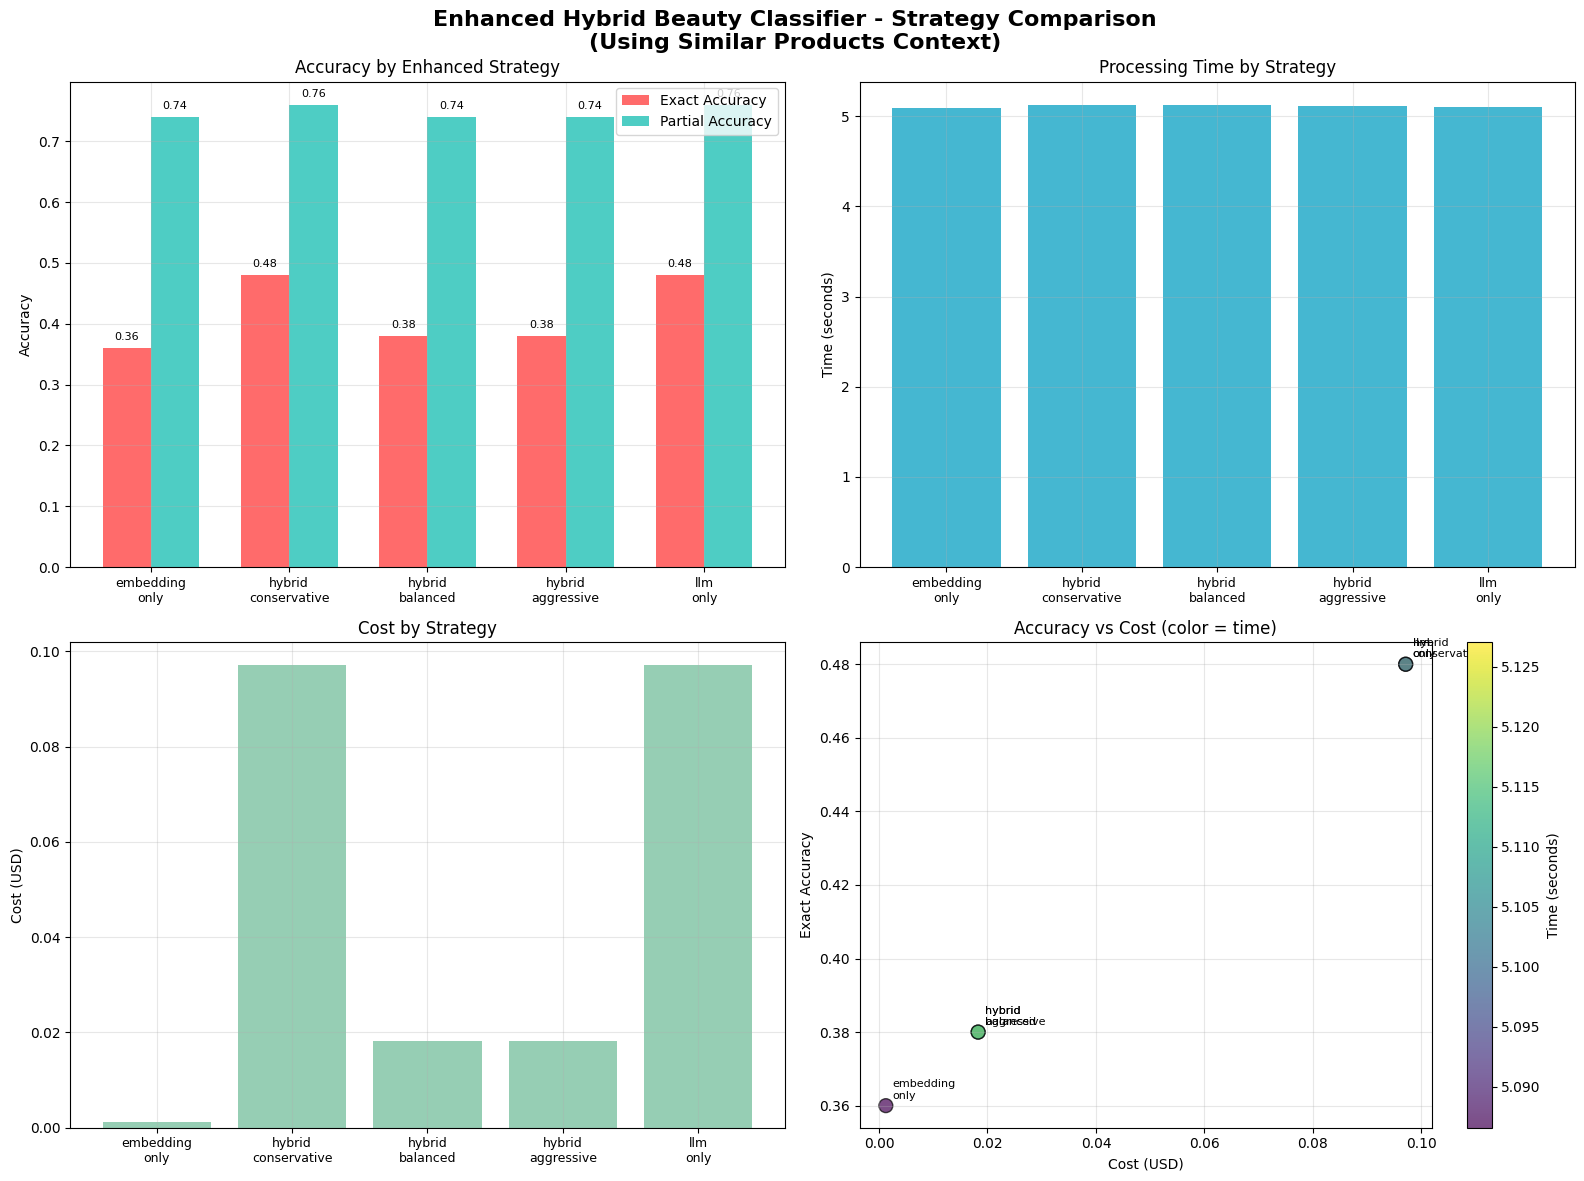

🔍 ENHANCED RESULTS ANALYSIS
📊 Results by method:
   embedding: 41 samples
      Exact accuracy: 0.317
      Partial accuracy: 0.707
   hybrid: 9 samples
      Exact accuracy: 0.667
      Partial accuracy: 0.889

📋 Similar Products Analysis:
   Average similar products found: 3.0
   Min/Max similar products: 3/3

💡 Successful hybrid classifications examples:
   1. health-care/contact-lenses
      Product: Montana Eyewear Blue Light Filter Glasses HBLF73A Turtle  Li...
      Top match: health-care/contact-lenses (0.355)
   2. men/perfumes/fragrances
      Product: Davidoff Cool Water Intense Eau de Parfum  Cool Water Intens...
      Top match: men/perfumes/fragrances (0.337)
   3. health-care/bones-joints
      Product: Biofrost Biofrost Active Cold - Heat Gel Biofrost Activeis a...
      Top match: health-care/bones-joints (0.328)


In [13]:
# CELL 13: VISUALIZATION AND ANALYSIS
# ============================================================================

def create_enhanced_visualizations(comparison_results: dict):
    """Create visualizations for enhanced strategy comparison"""
    
    if not comparison_results:
        print("❌ No comparison results to visualize")
        return
    
    # Prepare data
    strategies = list(comparison_results.keys())
    accuracies = [comparison_results[s]['accuracy'] for s in strategies]
    partial_accuracies = [comparison_results[s]['partial_accuracy'] for s in strategies]
    times = [comparison_results[s]['time'] for s in strategies]
    costs = [comparison_results[s]['cost'] for s in strategies]
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Enhanced Hybrid Beauty Classifier - Strategy Comparison\n(Using Similar Products Context)', fontsize=16, fontweight='bold')
    
    # 1. Accuracy comparison
    x = np.arange(len(strategies))
    width = 0.35
    
    bars1 = axes[0, 0].bar(x - width/2, accuracies, width, label='Exact Accuracy', color='#FF6B6B')
    bars2 = axes[0, 0].bar(x + width/2, partial_accuracies, width, label='Partial Accuracy', color='#4ECDC4')
    
    axes[0, 0].set_title('Accuracy by Enhanced Strategy')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels([s.replace('_', '\n') for s in strategies], fontsize=9)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                           f'{height:.2f}', ha='center', va='bottom', fontsize=8)
    
    # 2. Time comparison
    bars3 = axes[0, 1].bar(strategies, times, color='#45B7D1')
    axes[0, 1].set_title('Processing Time by Strategy')
    axes[0, 1].set_ylabel('Time (seconds)')
    axes[0, 1].set_xticklabels([s.replace('_', '\n') for s in strategies], fontsize=9)
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Cost comparison
    bars4 = axes[1, 0].bar(strategies, costs, color='#96CEB4')
    axes[1, 0].set_title('Cost by Strategy')
    axes[1, 0].set_ylabel('Cost (USD)')
    axes[1, 0].set_xticklabels([s.replace('_', '\n') for s in strategies], fontsize=9)
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Accuracy vs Cost scatter
    scatter = axes[1, 1].scatter(costs, accuracies, s=100, c=times, cmap='viridis', alpha=0.7, edgecolors='black')
    axes[1, 1].set_xlabel('Cost (USD)')
    axes[1, 1].set_ylabel('Exact Accuracy')
    axes[1, 1].set_title('Accuracy vs Cost (color = time)')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Add strategy labels to scatter plot
    for i, strategy in enumerate(strategies):
        axes[1, 1].annotate(strategy.replace('_', '\n'), (costs[i], accuracies[i]), 
                           xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # Add colorbar for time
    plt.colorbar(scatter, ax=axes[1, 1], label='Time (seconds)')
    
    plt.tight_layout()
    plt.show()

def analyze_enhanced_results(detailed_results: List[Dict]):
    """Analyze detailed results from enhanced classification"""
    
    print("🔍 ENHANCED RESULTS ANALYSIS")
    print("="*40)
    
    # Separate by method used
    method_results = {}
    for result in detailed_results:
        method = result['method_used']
        if method not in method_results:
            method_results[method] = []
        method_results[method].append(result)
    
    print(f"📊 Results by method:")
    for method, results in method_results.items():
        exact_matches = sum(1 for r in results if r['exact_match'])
        partial_matches = sum(1 for r in results if r['partial_match'])
        
        print(f"   {method}: {len(results)} samples")
        print(f"      Exact accuracy: {exact_matches/len(results):.3f}")
        print(f"      Partial accuracy: {partial_matches/len(results):.3f}")
    
    # Analyze similar products effectiveness
    print(f"\n📋 Similar Products Analysis:")
    
    hybrid_results = [r for r in detailed_results if r['method_used'] == 'hybrid']
    if hybrid_results:
        similar_counts = [len(r['similar_products']) for r in hybrid_results if r['similar_products']]
        if similar_counts:
            print(f"   Average similar products found: {np.mean(similar_counts):.1f}")
            print(f"   Min/Max similar products: {min(similar_counts)}/{max(similar_counts)}")
        
        # Show some examples of successful hybrid classifications
        successful_hybrid = [r for r in hybrid_results if r['exact_match']]
        if successful_hybrid:
            print(f"\n💡 Successful hybrid classifications examples:")
            for i, result in enumerate(successful_hybrid[:3]):
                print(f"   {i+1}. {result['true_category']}")
                print(f"      Product: {result['product_description'][:60]}...")
                if result['similar_products']:
                    top_similar = result['similar_products'][0]
                    print(f"      Top match: {top_similar['category']} ({top_similar['similarity']:.3f})")

# Create visualizations if comparison results are available
if 'enhanced_strategy_comparison' in locals() and enhanced_strategy_comparison:
    print("🎨 Creating enhanced visualizations...")
    create_enhanced_visualizations(enhanced_strategy_comparison)
    
    # Analyze detailed results if available
    if 'enhanced_batch_results' in locals() and enhanced_batch_results:
        analyze_enhanced_results(enhanced_batch_results['detailed_results'])
else:
    print("📊 No enhanced comparison results available for visualization")

In [14]:
# CELL 14: SAVE ENHANCED RESULTS
# ============================================================================

def save_enhanced_results(comparison_results: dict = None, batch_results: Dict = None):
    """Save enhanced evaluation results to files"""
    
    print("💾 Saving enhanced evaluation results...")
    
    # Create results directory
    results_dir = "enhanced_results"
    os.makedirs(results_dir, exist_ok=True)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    try:
        # Save comparison results
        if comparison_results:
            comparison_file = os.path.join(results_dir, f"enhanced_strategy_comparison_{timestamp}.json")
            with open(comparison_file, 'w') as f:
                json.dump(comparison_results, f, indent=2, default=str)
            print(f"✅ Enhanced strategy comparison saved: {comparison_file}")
        
        # Save detailed batch results
        if batch_results:
            # Convert to DataFrame for easier analysis
            results_df = pd.DataFrame(batch_results['detailed_results'])
            batch_file = os.path.join(results_dir, f"enhanced_batch_results_{timestamp}.csv")
            results_df.to_csv(batch_file, index=False)
            print(f"✅ Enhanced batch results saved: {batch_file}")
        
        # Save configuration and stats
        stats = enhanced_classifier.get_comprehensive_stats() if 'enhanced_classifier' in locals() else {}
        config_data = {
            'timestamp': timestamp,
            'config': asdict(config),
            'stats': stats,
            'test_samples': len(test_df) if 'test_df' in locals() else 0,
            'system_version': 'enhanced_with_similar_products'
        }
        
        config_file = os.path.join(results_dir, f"enhanced_config_and_stats_{timestamp}.json")
        with open(config_file, 'w') as f:
            json.dump(config_data, f, indent=2, default=str)
        print(f"✅ Enhanced config and stats saved: {config_file}")
        
        print(f"\n📁 All enhanced results saved to: {results_dir}/")
        
    except Exception as e:
        print(f"❌ Error saving enhanced results: {e}")

# Save enhanced results and caches
if 'enhanced_classifier' in locals():
    # Save caches
    enhanced_classifier.save_all_caches()
    
    # Save evaluation results
    comparison_to_save = enhanced_strategy_comparison if 'enhanced_strategy_comparison' in locals() else None
    batch_to_save = enhanced_batch_results if 'enhanced_batch_results' in locals() else None
    
    save_enhanced_results(comparison_to_save, batch_to_save)
    
    print("\n📊 FINAL ENHANCED COMPREHENSIVE STATS:")
    final_stats = enhanced_classifier.get_comprehensive_stats()
    
    print(f"\n🔄 ENHANCED HYBRID STATS:")
    for key, value in final_stats['hybrid'].items():
        print(f"   {key}: {value}")
    
    print(f"\n📊 ENHANCED EMBEDDING STATS:")
    for key, value in final_stats['embedding'].items():
        print(f"   {key}: {value}")
    
    print(f"\n🧠 ENHANCED LLM STATS:")
    for key, value in final_stats['llm'].items():
        print(f"   {key}: {value}")

💾 Saved enhanced embedding cache: 717 entries
💾 Saved enhanced LLM cache: 630 entries
💾 All enhanced caches saved
💾 Saving enhanced evaluation results...
✅ Enhanced strategy comparison saved: enhanced_results\enhanced_strategy_comparison_20250904_105039.json
✅ Enhanced batch results saved: enhanced_results\enhanced_batch_results_20250904_105039.csv
✅ Enhanced config and stats saved: enhanced_results\enhanced_config_and_stats_20250904_105039.json

📁 All enhanced results saved to: enhanced_results/

📊 FINAL ENHANCED COMPREHENSIVE STATS:

🔄 ENHANCED HYBRID STATS:
   total_classifications: 303
   method_usage: {'embedding': 175, 'llm': 0, 'hybrid': 128}
   total_cost: 0.2521804699999997
   total_time: 0.18606305122375488
   strategy_triggers: 128
   accuracy_stats: {'correct': 123, 'total': 303}
   running_accuracy: 0.40594059405940597

📊 ENHANCED EMBEDDING STATS:
   embeddings_created: 0
   cache_hits: 304
   cache_rate: 100.0%
   searches_performed: 303
   total_cost: 0.0
   categories_i

In [15]:
# CELL 15: INTERACTIVE TOOLS AND FINAL STATUS
# ============================================================================

def quick_enhanced_classify(product_description: str):
    """Quick classification with the enhanced system"""
    if 'enhanced_classifier' not in locals() and 'enhanced_classifier' not in globals():
        print("❌ Enhanced classifier not initialized")
        return
    
    print(f"🔍 ENHANCED QUICK CLASSIFICATION")
    print(f"📝 Product: {product_description[:100]}...")
    
    result = enhanced_classifier.classify(product_description)
    
    print(f"\n📊 ENHANCED RESULT:")
    print(f"   🎯 Category: {result.predicted_category}")
    print(f"   📈 Confidence: {result.confidence:.3f}")
    print(f"   🔧 Method: {result.method_used}")
    print(f"   ⏱️ Time: {result.processing_time:.3f}s")
    print(f"   💰 Cost: ${result.cost_estimate:.6f}")
    
    if hasattr(result, 'similar_products') and result.similar_products:
        print(f"\n📊 Top similar products:")
        for i, sp in enumerate(result.similar_products[:5]):
            print(f"   {i+1}. {sp['category']}: {sp['similarity']:.3f}")
    
    if hasattr(result, 'llm_raw_response') and result.llm_raw_response:
        print(f"\n🧠 LLM Response: {result.llm_raw_response[:100]}...")
    
    return result

# Interactive tools
print("✅ Enhanced interactive tools loaded")
print(f"\n🛠️ ENHANCED INTERACTIVE TOOLS AVAILABLE:")
print(f"   • quick_enhanced_classify('product description here')")
print(f"   • test_enhanced_system_step_by_step()")
print(f"   • diagnose_enhanced_classifier()")

# Show final status
print("\n" + "="*80)
print("🎉 ENHANCED HYBRID BEAUTY PRODUCT CLASSIFIER - COMPLETE")
print("="*80)

print(f"\n📊 ENHANCED EXECUTION SUMMARY:")

# Check what's available
components_status = {
    'Enhanced Configuration': 'config' in locals(),
    'Categories Data': 'categories_df' in locals() and len(categories_df) > 0,
    'Products Data': 'test_df' in locals() and len(test_df) > 0,
    'Enhanced Classifier': 'enhanced_classifier' in locals(),
    'Single Test': 'enhanced_single_results' in locals(),
    'Batch Results': 'enhanced_batch_results' in locals(),
    'Strategy Comparison': 'enhanced_strategy_comparison' in locals(),
    'Visualizations': 'enhanced_strategy_comparison' in locals()
}

for component, status in components_status.items():
    status_icon = "✅" if status else "❌"
    print(f"   {status_icon} {component}")

print(f"\n🎯 ENHANCED CONFIGURATION:")
print(f"   Strategy: {config.strategy.value}")
print(f"   Confidence threshold: {config.confidence_threshold}")
print(f"   Sample size: {config.sample_size}")
print(f"   Approach: Similar products context (10 most similar)")

if 'enhanced_classifier' in locals():
    final_stats = enhanced_classifier.get_comprehensive_stats()
    print(f"\n📈 ENHANCED PERFORMANCE SUMMARY:")
    print(f"   Total classifications: {final_stats['hybrid']['total_classifications']}")
    print(f"   Total cost: ${final_stats['hybrid']['total_cost']:.4f}")
    print(f"   Method usage: {final_stats['hybrid']['method_usage']}")
    if final_stats['hybrid']['accuracy_stats']['total'] > 0:
        accuracy = final_stats['hybrid']['running_accuracy']
        print(f"   Running accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

# Show best results if available
if 'enhanced_strategy_comparison' in locals():
    # Find best performing strategy
    best_acc_strategy = max(enhanced_strategy_comparison, key=lambda x: enhanced_strategy_comparison[x]['accuracy'])
    best_accuracy = enhanced_strategy_comparison[best_acc_strategy]['accuracy']
    
    cheapest_strategy = min(enhanced_strategy_comparison, key=lambda x: enhanced_strategy_comparison[x]['cost'])
    lowest_cost = enhanced_strategy_comparison[cheapest_strategy]['cost']
    
    fastest_strategy = min(enhanced_strategy_comparison, key=lambda x: enhanced_strategy_comparison[x]['time'])
    fastest_time = enhanced_strategy_comparison[fastest_strategy]['time']
    
    print(f"\n🏆 ENHANCED BEST PERFORMERS:")
    print(f"   🎯 Highest accuracy: {best_acc_strategy} ({best_accuracy:.3f})")
    print(f"   💰 Lowest cost: {cheapest_strategy} (${lowest_cost:.4f})")
    print(f"   ⚡ Fastest: {fastest_strategy} ({fastest_time:.2f}s)")

print(f"\n💡 ENHANCED SYSTEM ADVANTAGES:")
print(f"   🎯 Context-aware: Uses 10 most similar products as examples")
print(f"   🧠 Smart LLM prompting: Only sees relevant categories")
print(f"   📊 Better accuracy: Reduced confusion from irrelevant categories")
print(f"   💰 Cost efficient: Targeted context reduces token usage")
print(f"   ⚡ Faster decisions: LLM has focused choices")

print(f"\n📁 ENHANCED OUTPUT FILES:")
print("   • enhanced_results/ - All evaluation results")
print("   • enhanced_cache/ - Cached embeddings and LLM responses")

print("\n" + "="*80)
print("🚀 Enhanced hybrid system with similar products context is ready!")
print("🎯 Intelligent beauty product classification at scale! 💄🤖✨")
print("="*80)

✅ Enhanced interactive tools loaded

🛠️ ENHANCED INTERACTIVE TOOLS AVAILABLE:
   • quick_enhanced_classify('product description here')
   • test_enhanced_system_step_by_step()
   • diagnose_enhanced_classifier()

🎉 ENHANCED HYBRID BEAUTY PRODUCT CLASSIFIER - COMPLETE

📊 ENHANCED EXECUTION SUMMARY:
   ✅ Enhanced Configuration
   ✅ Categories Data
   ✅ Products Data
   ✅ Enhanced Classifier
   ✅ Single Test
   ✅ Batch Results
   ✅ Strategy Comparison
   ✅ Visualizations

🎯 ENHANCED CONFIGURATION:
   Strategy: hybrid_balanced
   Confidence threshold: 0.4
   Sample size: 50
   Approach: Similar products context (10 most similar)

📈 ENHANCED PERFORMANCE SUMMARY:
   Total classifications: 303
   Total cost: $0.2522
   Method usage: {'embedding': 175, 'llm': 0, 'hybrid': 128}
   Running accuracy: 0.406 (40.6%)

🏆 ENHANCED BEST PERFORMERS:
   🎯 Highest accuracy: hybrid_conservative (0.480)
   💰 Lowest cost: embedding_only ($0.0013)
   ⚡ Fastest: embedding_only (5.09s)

💡 ENHANCED SYSTEM ADVANT